# How to generate a utility report?

Assume that the synthetic data is already generated \
Based on the Wisconsin Breast Cancer Dataset

In [1]:
import sys  # standard library

sys.path.append("..")

import pandas as pd  # 3rd party packages

import config  # local packages
import utils.draw
from metrics.utility.report import Report

## Load the real and synthetic WBCD datasets

In [2]:
df_real = pd.read_csv("../data/" + config.WBCD_DATASET_FILENAME)
df_real = df_real.drop(columns="Sample_code_number")
df_real["Class"] = (df_real["Class"] / 2 - 1).astype(
    int
)  # Class 0 or 1 instead of 2 and 4
df_real.shape

(683, 10)

### Choose the synthetic dataset

Synthpop ordered

In [3]:
df_synth = pd.read_csv("../results/data/2023-02-20_Synthpop_683samples_ordered.csv")

## Configure the type of the variables

In [4]:
metadata = {
    "continuous": [
        "Clump_Thickness",
        "Uniformity_of_Cell_Size",
        "Uniformity_of_Cell_Shape",
        "Marginal_Adhesion",
        "Single_Epithelial_Cell_Size",
        "Bland_Chromatin",
        "Normal_Nucleoli",
        "Mitoses",
        "Bare_Nuclei",
    ],
    "categorical": ["Class"],
    "variable_to_predict": "Class",
}

## Compare the distributions

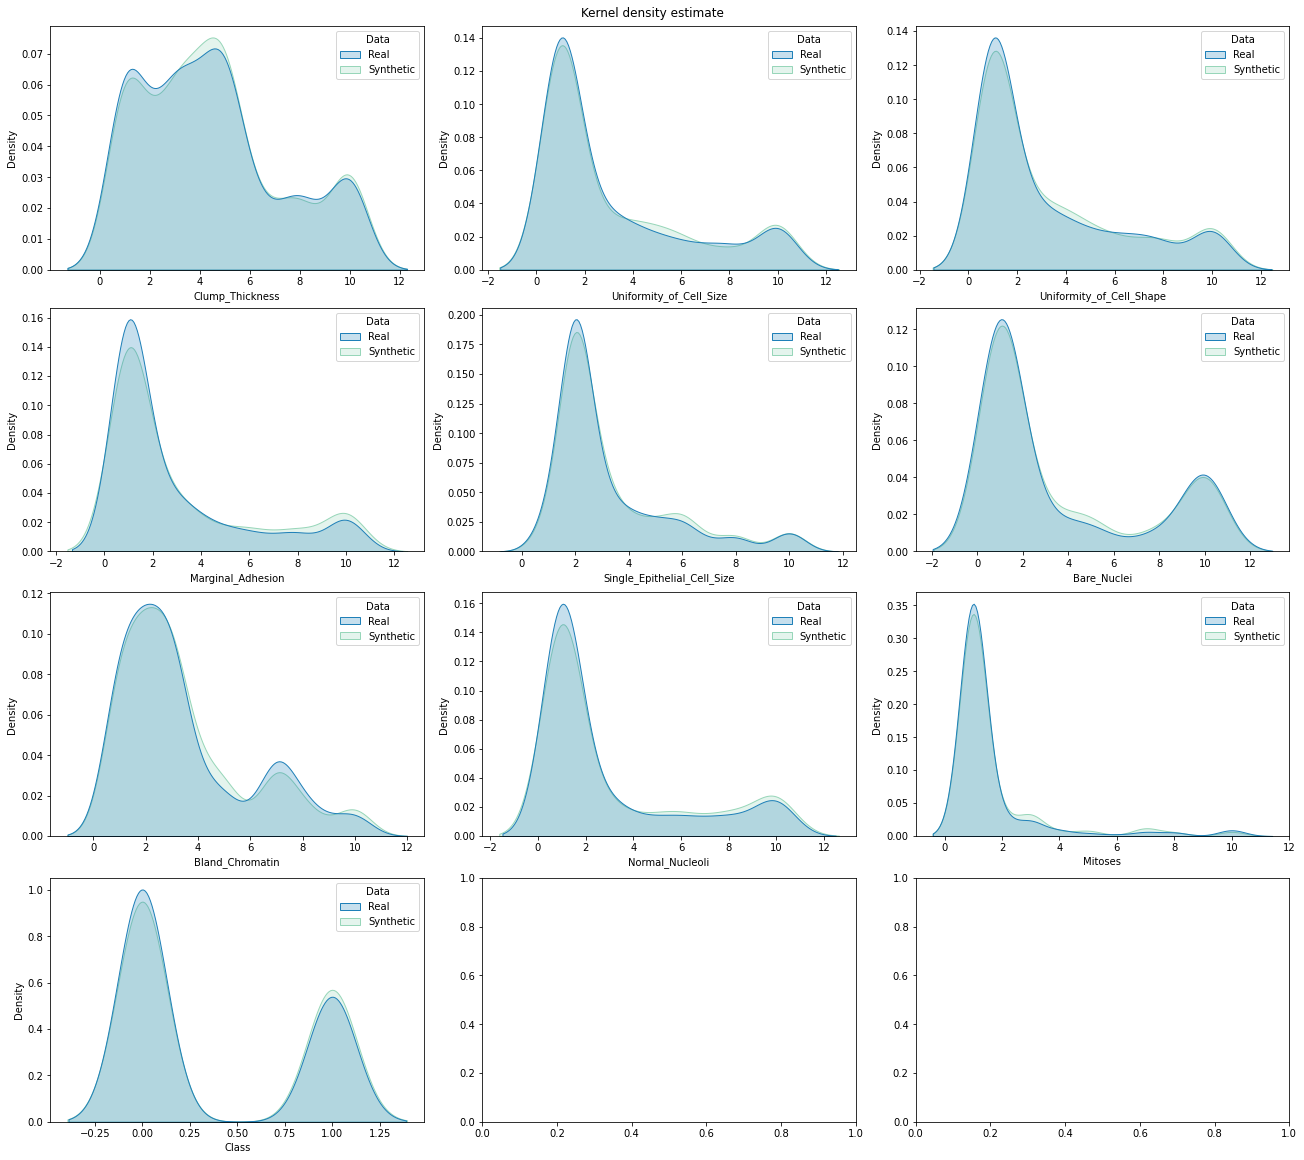

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(  # manually set number of cols/rows
    nrows=4, ncols=3, squeeze=0, figsize=(18, 16), layout="constrained"
)
axes = axes.reshape(-1)
utils.draw.kde_plot_hue_plot_per_col(
    df=df_real,
    df_nested=df_synth,
    original_name="Real",
    nested_name="Synthetic",
    hue_name="Data",
    title="Kernel density estimate",
    axes=axes,
)

## Generate the utility report

Some metrics will not be computed since the only categorical variable is the variable to predict 

### First option: Create and compute the full utility report - it takes some time

In [6]:
report = Report(
    dataset_name="Wisconsin Breast Cancer Dataset",
    df_real=df_real,
    df_synthetic=df_synth,
    metadata=metadata,
    num_repeat=3,  # for the metrics relying on predictions
    num_folds=3,  # for the metrics relying on predictions
    alpha=0.05,  # for the pairwise chi-square metric
    figsize=(8, 6),  # will be automatically adjusted for larger or longer figures
    random_state=0,  # for reproducibility purposes
)

In [7]:
report.compute()

#### Get the summary report as a pandas dataframe

In [8]:
report.specification()

----- Wisconsin Breast Cancer Dataset -----
Contains:
    - 683 instances,
    - 10 variables, 9 continuous and 1 categorical.


In [9]:
df_summary = report.summary()

In [10]:
by = ["name", "objective", "min", "max"]
df_summary.groupby(by).apply(lambda x: x.drop(by, axis=1).reset_index(drop=True))

submetric  \
name                                          objective min max                         
Categorical Consistency                       max       0   1.0 0        within_ratio   
Categorical Statistics                        max       0   1.0 0    support_coverage   
                                                                1  frequency_coverage   
Classification                                min       0   1.0 0     diff_real_train   
                                                                1    diff_synth_train   
                                                                2     diff_real_synth   
Continuous Consistency                        max       0   1.0 0        within_ratio   
Continuous Statistics                         min       0   inf 0  median_l1_distance   
                                                                1     iqr_l1_distance   
Cross Classification                          min       0   1.0 0          real_train   
                                                                1         synth_train   
Cross Regression                              min       0   inf 0          real_train   
                                                                1         synth_train   
Distinguishability                            min       0   1.0 0      propensity_mse   
                                                                1      prediction_mse   
                                                                2      prediction_auc   
FScore                                        min       0   inf 0        diff_f_score   
Hellinger Categorical Univariate Distance     min       0   1.0 0  hellinger_distance   
Hellinger Continuous Univariate Distance      min       0   1.0 0  hellinger_distance   
KL Divergence Categorical Univariate Distance min       0   inf 0       kl_divergence   
KL Divergence Continuous Univariate Distance  min       0   inf 0       kl_divergence   
Pairwise Correlation Difference               min       0   inf 0                norm   

                                                                      value  
name                                          objective min max              
Categorical Consistency                       max       0   1.0 0  1.000000  
Categorical Statistics                        max       0   1.0 0  1.000000  
                                                                1  0.975110  
Classification                                min       0   1.0 0  0.003804  
                                                                1  0.002118  
                                                                2  0.002991  
Continuous Consistency                        max       0   1.0 0  1.000000  
Continuous Statistics                         min       0   inf 0  0.012346  
                                                                1  0.024691  
Cross Classification                          min       0   1.0 0  0.001488  
                                                                1  0.001745  
Cross Regression                              min       0   inf 0  0.577483  
                                                                1  0.221319  
Distinguishability                            min       0   1.0 0  0.037861  
                                                                1  0.064316  
                                                                2  0.000000  
FScore                                        min       0   inf 0  0.114737  
Hellinger Categorical Univariate Distance     min       0   1.0 0  0.018309  
Hellinger Continuous Univariate Distance      min       0   1.0 0  0.043674  
KL Divergence Categorical Univariate Distance min       0   inf 0  0.001348  
KL Divergence Continuous Univariate Distance  min       0   inf 0  0.008203  
Pairwise Correlation Difference               min       0   inf 0  0.245490

#### Display the detailed report

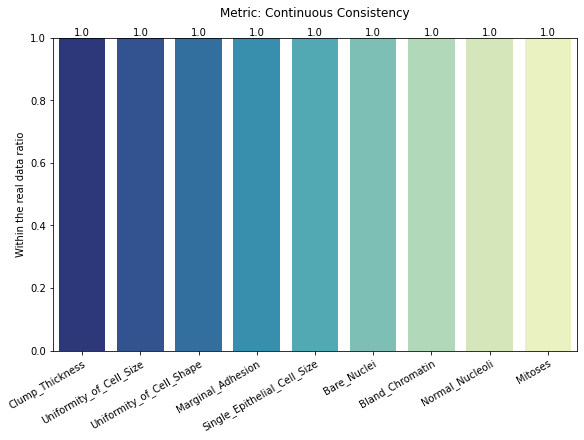

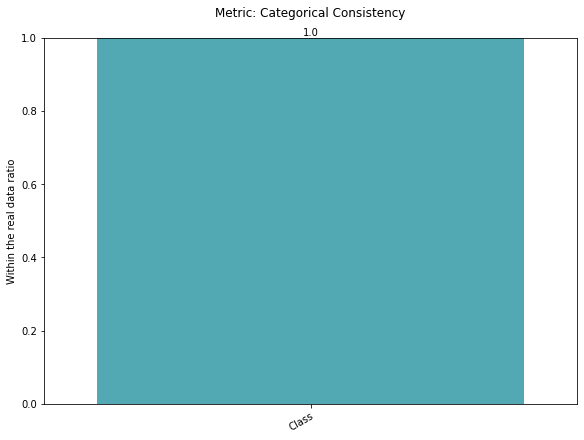

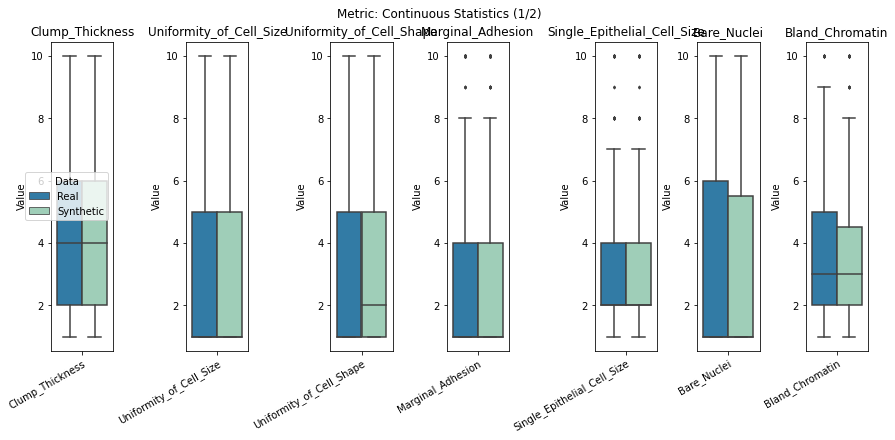

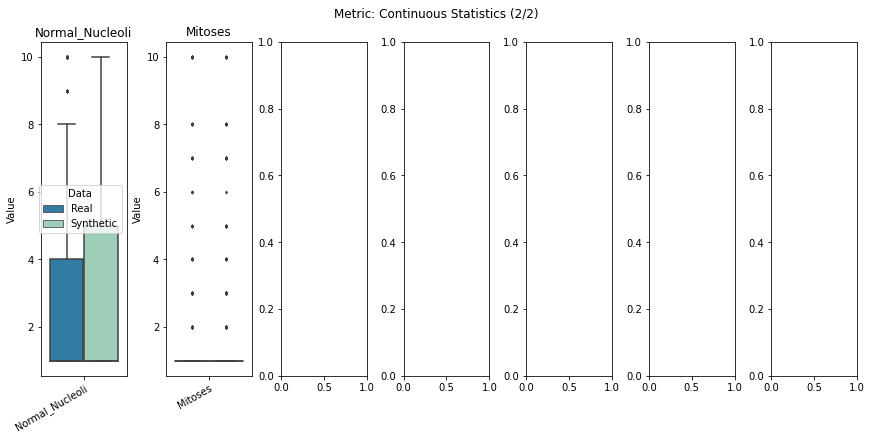

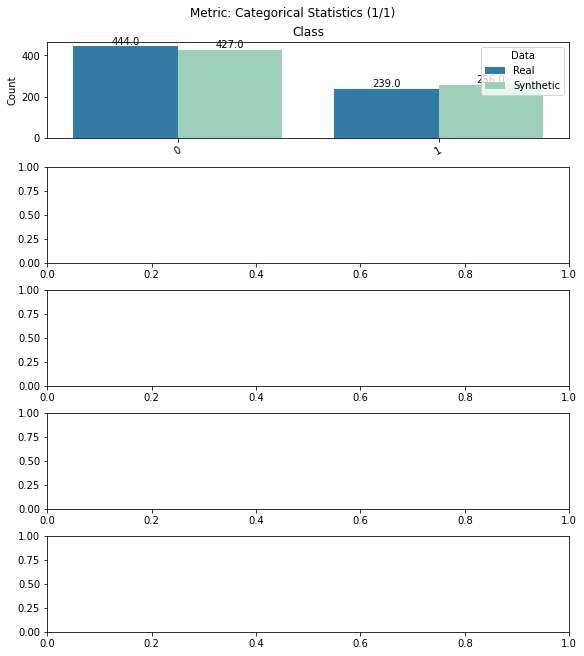

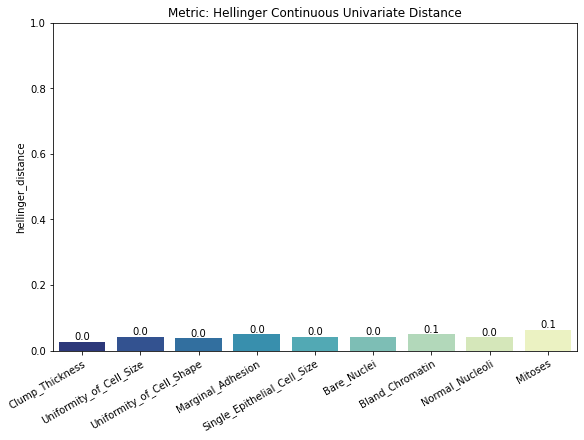

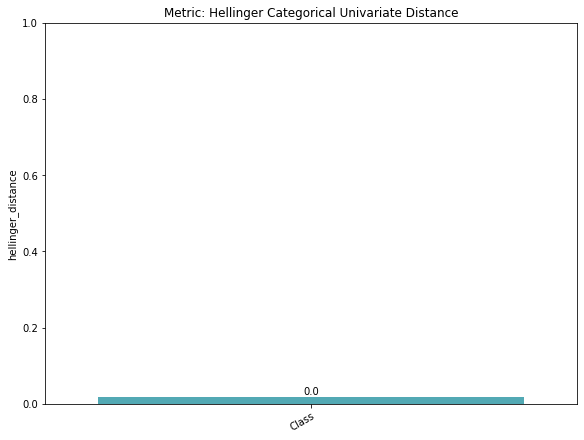

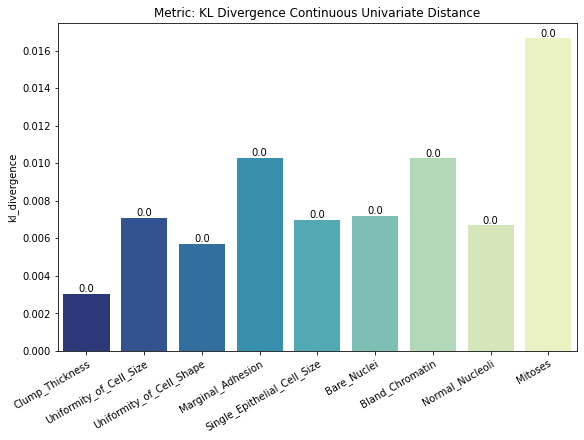

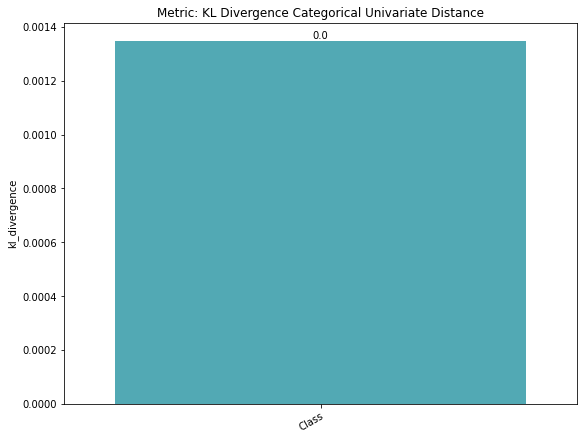

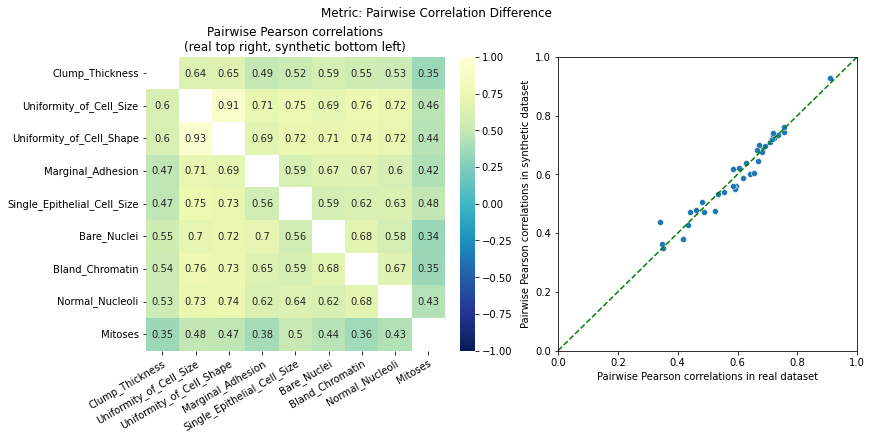

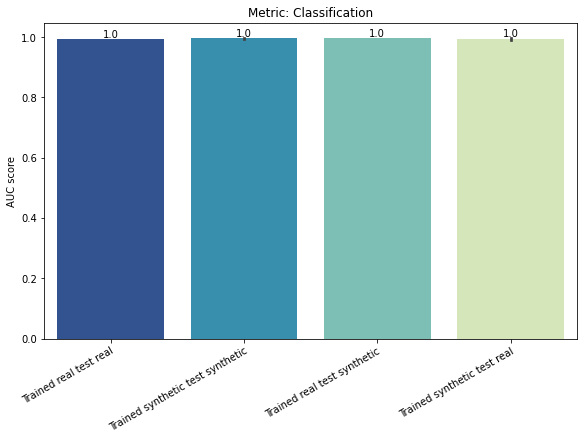

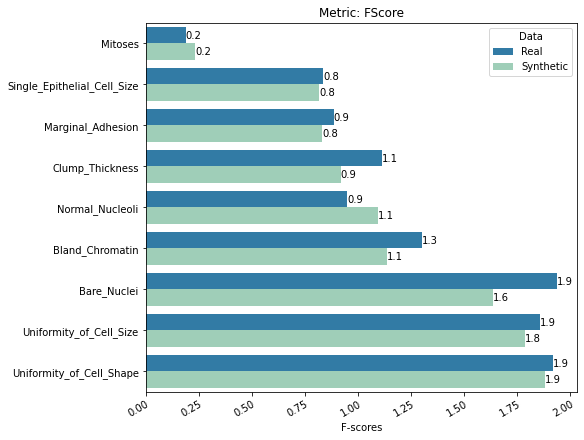

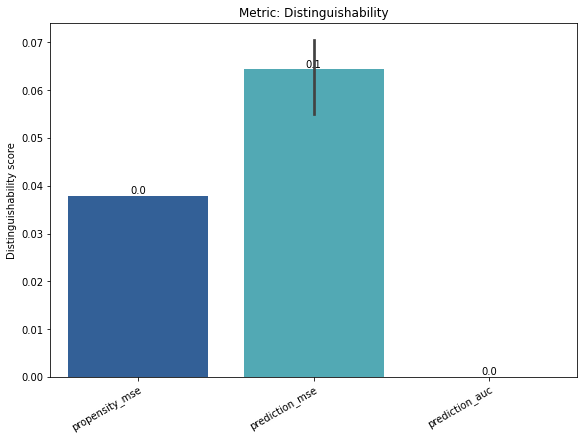

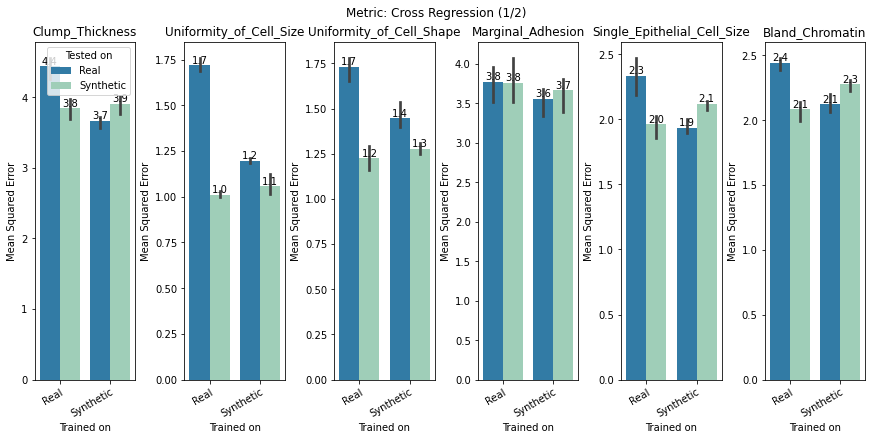

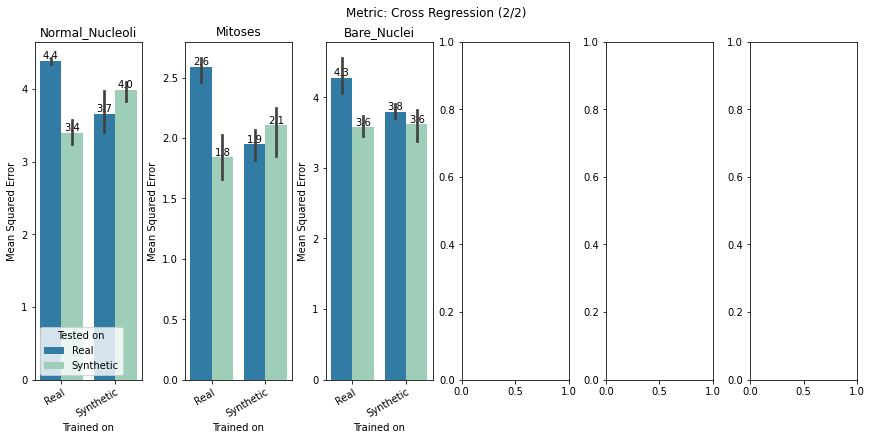

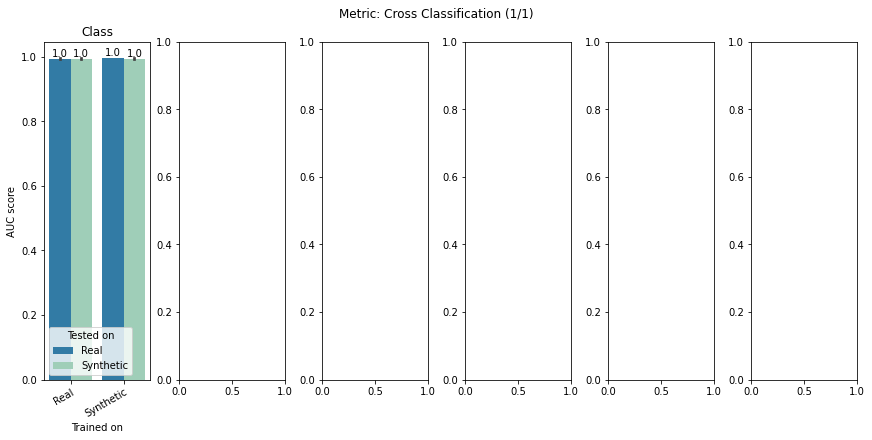

In [11]:
report.detailed(show=True, save_folder=None, figure_format="png")

#### To display only one metric, the draw function can be used

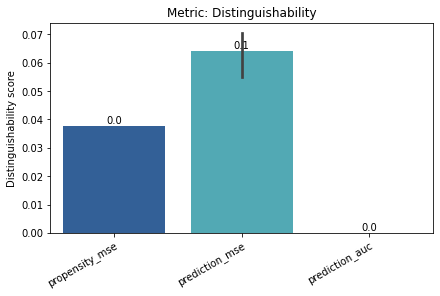

In [12]:
report.draw(
    metric_name="Distinguishability",
    figsize=(6, 4),
    show=True,
    save_folder=None,
    figure_format="png",
)

### Second option: Create and compute the report for a subset of metrics only

#### Here only compute the Distinguishability metric

In [13]:
report = Report(
    dataset_name="Wisconsin Breast Cancer Dataset",
    df_real=df_real,
    df_synthetic=df_synth,
    metadata=metadata,
    metrics=["Distinguishability"],  # the subset of metrics to compute
    num_repeat=3,
    num_folds=3,
    alpha=0.05,
)

In [14]:
report.compute()

In [15]:
report.summary()

,name,submetric,value,objective,min,max
0,Distinguishability,propensity_mse,0.037861,min,0,1
1,Distinguishability,prediction_mse,0.065253,min,0,1
2,Distinguishability,prediction_auc,0.000000,min,0,1


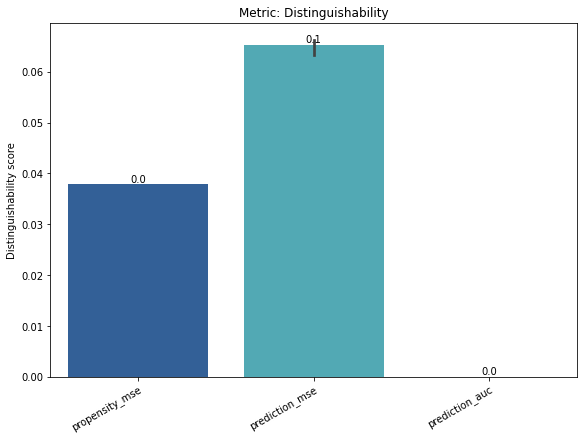

In [16]:
report.detailed(show=True, save_folder=None, figure_format="png")